In [1]:
import numpy as np
import pandas as pd

## Step 1: Load the Dataset

In [2]:
df = pd.read_csv('Data_Train_Feature_Scaled.csv')

## Step 2: Separate Features and Target

In [3]:
X = df.drop('Price', axis = 1)
y =  df['Price']

### Step 3: Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state =  42 )

### Step 4: Import Linear Regression

In [10]:
from sklearn.linear_model import LinearRegression

# Creating the model 
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

### Step 5: Evaluate

In [12]:
from sklearn.metrics import (
                        mean_absolute_error,
                        mean_squared_error,
                        root_mean_squared_error,
                        r2_score)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print('MAE :', mae)
print('MSE :', mse)
print('RMSE :', rmse)
print('R2 :', r2)

MAE : 1735.1017793663768
MSE : 5989248.076338997
RMSE : 2447.2940314435036
R2 : 0.7069495233754213


## What do these results tell you?

✅ Your Linear Regression model has learned meaningful relationships from the data.

✅ An R² of about 0.71 is a solid baseline for many real-world regression problems.

⚠️ The fact that RMSE is noticeably higher than MAE suggests there are some flights where the model makes substantially larger errors. Investigating those cases (for example, unusual routes or very expensive tickets) can often reveal opportunities for feature engineering or trying more flexible models.

In other words, your first model isn't perfect, but it has captured a significant amount of the underlying signal. That's exactly what you want from a baseline: something that works reasonably well and gives you a benchmark against which more advanced models like Decision Trees, Random Forests, or Gradient Boosting can be compared.

### Step 6: Viewing  Coefficients

In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Total_Stops,906.134923
1,Journey_Day,-573.693215
2,Journey_Month,41.052108
3,Journey_Weekday,161.365322
4,Journey_DayOfWeek,80.415773
...,...,...
158,Route_DEL → PNQ → COK,-763.230688
159,Route_DEL → RPR → NAG → BOM → COK,-2835.340903
160,Route_DEL → TRV → COK,-1289.948785
161,Route_DEL → UDR → BOM → COK,1152.745452


### Step 7: Check the Intercept

In [16]:
model.intercept_

np.float64(11584.451449432572)

### Step 8: Compare the Actual values vs the predicted ones

In [17]:
comparison = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred
})

comparison.head()

,Actual,Predicted
10068,15058,10740.719841
3023,10844,10767.088976
10386,14424,12987.078159
10361,57209,55093.815147
10270,6628,9035.326745


### Step 9: Visualize the prediction

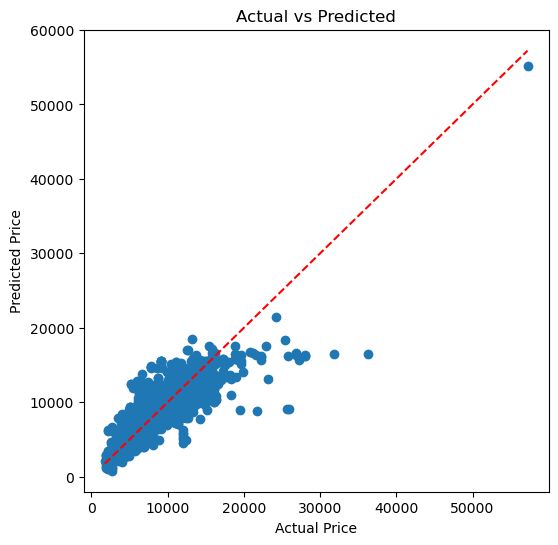

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.show()